### CS303 Machine Learning Lab
### Experiment 5 : Polynomial Regression, Overfitting Analysis, Ridge (L2) and Lasso (L1) Regularisation
**Student Name:** Jyotiraditya Rajesh Ganvir  
**Roll Number:** 24/CS/232  


**Aim:**
To study polynomial regression and the effect of increasing model complexity on training and testing errors, identify overfitting, and apply Ridge (L2) and Lasso (L1) regularisation to control model complexity and reduce overfitting.

**Objectives:**
1. Load the housing price dataset, isolate the continuous feature (`area`) and target variable (`price`), and drop all other columns.
2. Implement polynomial feature transformations for degrees $d \in \{1, 3, 5, 7, 10\}$.
3. Evaluate training MSE, testing MSE, and $R^2$ scores across all degrees to quantify the generalization gap and detect the onset of overfitting.
4. Isolate the highest-degree overfitted polynomial model ($d=10$) and visualize the oscillation in its fitted regression curve.
5. Apply Ridge ($L_2$) regularisation to shrink coefficient magnitudes toward zero.
6. Apply Lasso ($L_1$) regularisation to induce sparsity by driving uninformative polynomial coefficients to absolute zero.
7. Compare model performance across unregularised, Ridge, and Lasso pipelines using error plots, curve fits, and coefficient distributions.

**1. Importing Libraries & Loading the Dataset**

The housing dataset is loaded directly from the repository. All extraneous columns are discarded, retaining only the independent variable (`area`) and the target variable (`price`).

In [1]:
# import data manipulation, modeling, and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# load the dataset from the repository url
url = "https://github.com/JyRaGa/CS303-Machine-Learning_Coursework/raw/refs/heads/main/datasets/Housing.csv"
df_raw = pd.read_csv(url)

# isolate only the 2 required columns: area (x) and price (y)
df = df_raw[['area', 'price']].copy()

# display summary information
print("--- Dataset Dimensions & Structure ---")
print(f"Total Samples: {df.shape[0]}, Features Retained: {df.columns.tolist()}")
print("\n--- First 5 Records ---")
display(df.head())

--- Dataset Dimensions & Structure ---
Total Samples: 545, Features Retained: ['area', 'price']

--- First 5 Records ---


,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


**2. Exploratory Data Visualization & Train-Test Splitting**

A 70:30 train-test split is executed with a fixed random seed to ensure strict experimental reproducibility.

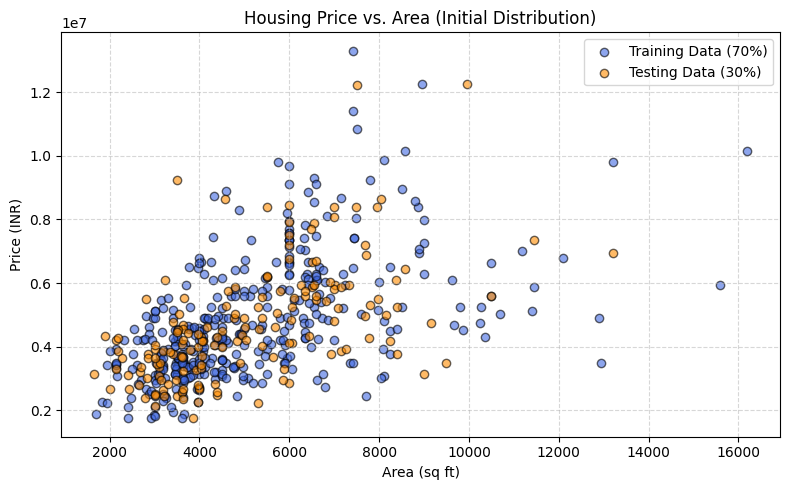

In [2]:
# separate predictor (x) and response variable (y)
X = df[['area']]
y = df['price']

# split into training (70%) and testing (30%) subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=22)

# visualize the raw scatter distribution of the training and testing sets
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='royalblue', alpha=0.6, label='Training Data (70%)', edgecolor='k')
plt.scatter(X_test, y_test, color='darkorange', alpha=0.6, label='Testing Data (30%)', edgecolor='k')
plt.title('Housing Price vs. Area (Initial Distribution)')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**3. Polynomial Regression Across Increasing Degrees (d = 1, 3, 5, 7, 10)**

For each polynomial degree, a scikit-learn pipeline is constructed consisting of `PolynomialFeatures`, `StandardScaler` (to normalize higher-order exponents and avoid floating-point overflow), and `LinearRegression`.

In [3]:
# define target degrees for complexity analysis
degrees = [1, 3, 5, 7, 10]
results = []
models = {}

# evaluate polynomial models across degrees
for d in degrees:
    # assemble pipeline with scaling to prevent numeric instability
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('linear', LinearRegression())
    ])

    # train model on training partition
    pipe.fit(X_train, y_train)
    models[d] = pipe

    # generate in-sample and out-of-sample predictions
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # calculate evaluation metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # append metric records
    results.append({
        'Degree': d,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Generalization Gap (Test - Train MSE)': test_mse - train_mse
    })

# compile metrics into a structured dataframe
metrics_df = pd.DataFrame(results)
print("=" * 95)
print("POLYNOMIAL REGRESSION ERROR ANALYSIS ACROSS DEGREES")
print("=" * 95)
display(metrics_df[['Degree', 'Train MSE', 'Test MSE', 'Train R2', 'Test R2', 'Generalization Gap (Test - Train MSE)']])

POLYNOMIAL REGRESSION ERROR ANALYSIS ACROSS DEGREES


,Degree,Train MSE,Test MSE,Train R2,Test R2,Generalization Gap (Test - Train MSE)
0,1,2.572508e+12,2.297103e+12,0.278806,0.307038,-2.754042e+11
1,3,2.388491e+12,2.302480e+12,0.330395,0.305416,-8.601040e+10
2,5,2.300878e+12,2.253351e+12,0.354957,0.320236,-4.752646e+10
3,7,2.286829e+12,2.247808e+12,0.358895,0.321909,-3.902063e+10
4,10,2.268389e+12,2.297794e+12,0.364065,0.306830,2.940535e+10


**4. Visualizing Overfitting: Polynomial Fit Curves vs. Generalization Gap**

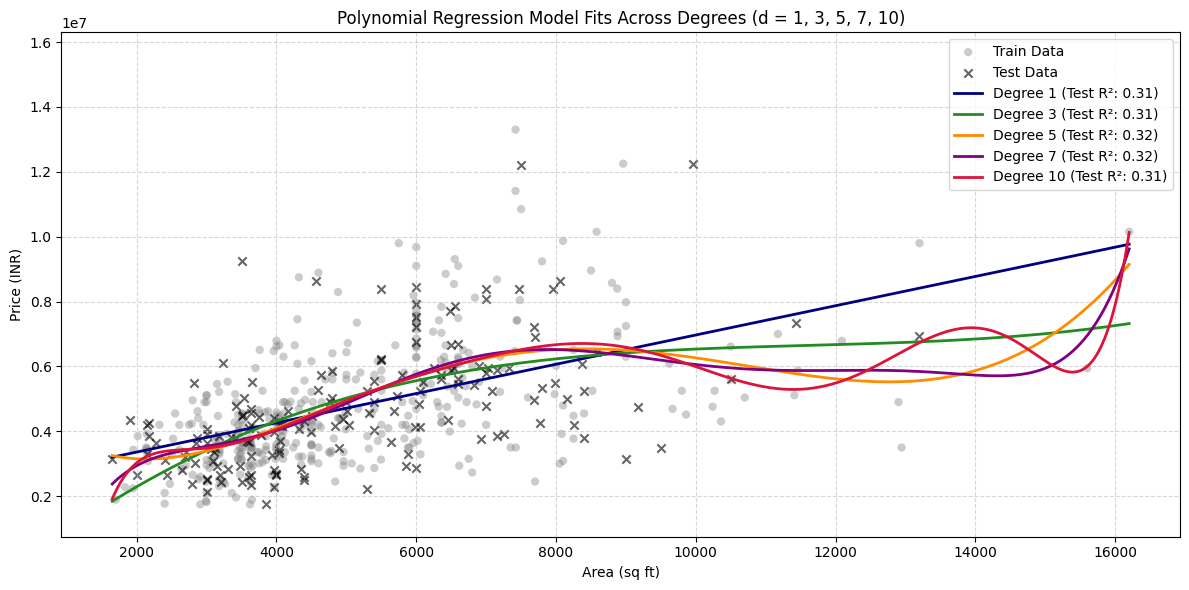

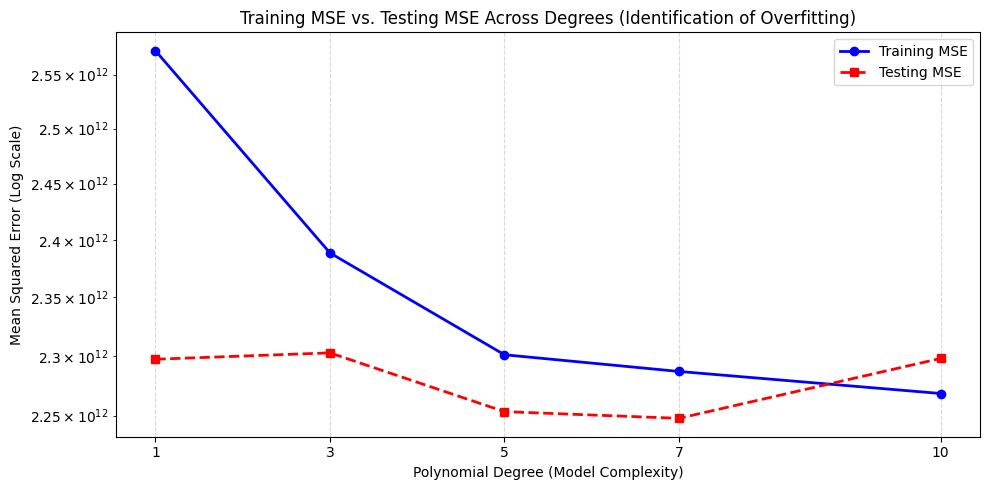

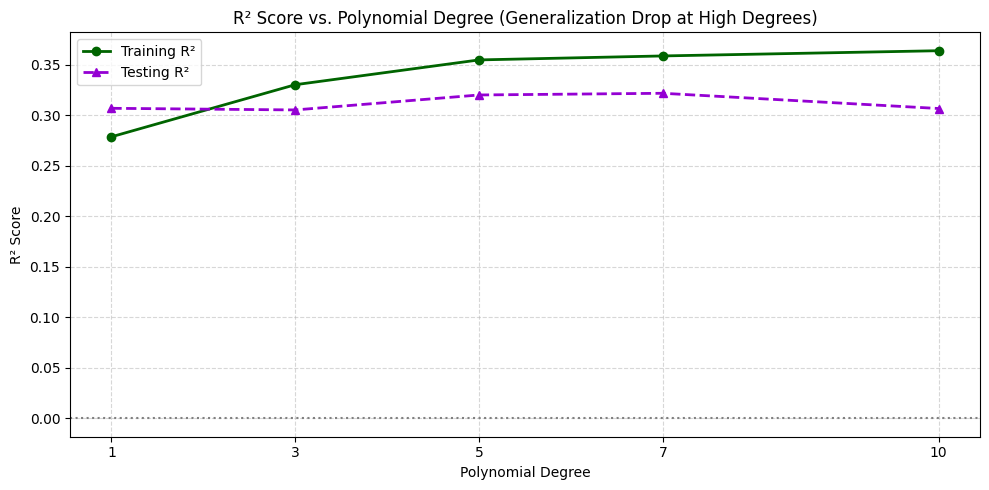

In [4]:
# create a continuous domain mesh for plotting smooth regression curves
x_range = np.linspace(X['area'].min(), X['area'].max(), 500).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=['area'])

# 1. Plot polynomial regression curves against observed data
plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, color='gray', alpha=0.4, label='Train Data', edgecolor='none')
plt.scatter(X_test, y_test, color='black', alpha=0.6, label='Test Data', marker='x')

colors = ['navy', 'forestgreen', 'darkorange', 'purple', 'crimson']
for d, color in zip(degrees, colors):
    y_curve = models[d].predict(x_range_df)
    plt.plot(x_range, y_curve, label=f'Degree {d} (Test R²: {metrics_df.loc[metrics_df["Degree"]==d, "Test R2"].values[0]:.2f})', color=color, lw=2)

plt.ylim(y.min() - 1e6, y.max() + 3e6)
plt.title('Polynomial Regression Model Fits Across Degrees (d = 1, 3, 5, 7, 10)')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Plot Training vs Testing MSE (Log-Scale) showing the Generalization Gap
plt.figure(figsize=(10, 5))
plt.plot(metrics_df['Degree'], metrics_df['Train MSE'], marker='o', color='blue', lw=2, label='Training MSE')
plt.plot(metrics_df['Degree'], metrics_df['Test MSE'], marker='s', color='red', lw=2, linestyle='--', label='Testing MSE')
plt.yscale('log')
plt.title('Training MSE vs. Testing MSE Across Degrees (Identification of Overfitting)')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Plot Training vs Testing R2 Score Across Degrees
plt.figure(figsize=(10, 5))
plt.plot(metrics_df['Degree'], metrics_df['Train R2'], marker='o', color='darkgreen', lw=2, label='Training R²')
plt.plot(metrics_df['Degree'], metrics_df['Test R2'], marker='^', color='darkviolet', lw=2, linestyle='--', label='Testing R²')
plt.axhline(0, color='gray', linestyle=':')
plt.title('R² Score vs. Polynomial Degree (Generalization Drop at High Degrees)')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**5. Regularisation: Applying Ridge (L2) and Lasso (L1) on the Overfitted Degree-10 Model**

To mitigate extreme coefficient explosion and control model variance at degree 10, Ridge ($L_2$) and Lasso ($L_1$) regularisation penalties are applied:
- **Ridge Cost:** $J(\theta) = \text{MSE} + \alpha \sum_{j=1}^{p} \theta_j^2$
- **Lasso Cost:** $J(\theta) = \text{MSE} + \alpha \sum_{j=1}^{p} |\theta_j|$

In [5]:
# target the high-complexity overfit model: degree 10
d_target = 10

# 1. Unregularised OLS Degree-10 Model
pipe_ols10 = Pipeline([
    ('poly', PolynomialFeatures(degree=d_target, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipe_ols10.fit(X_train, y_train)
pred_ols10 = pipe_ols10.predict(X_test)

# 2. Ridge (L2) Regularised Degree-10 Model
alpha_ridge = 100.0
pipe_ridge10 = Pipeline([
    ('poly', PolynomialFeatures(degree=d_target, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=alpha_ridge))
])
pipe_ridge10.fit(X_train, y_train)
pred_ridge10 = pipe_ridge10.predict(X_test)

# 3. Lasso (L1) Regularised Degree-10 Model
alpha_lasso = 10000.0
pipe_lasso10 = Pipeline([
    ('poly', PolynomialFeatures(degree=d_target, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=alpha_lasso, max_iter=20000))
])
pipe_lasso10.fit(X_train, y_train)
pred_lasso10 = pipe_lasso10.predict(X_test)

# 4. Intermediate Degree-3 Pipeline with Gentle Regularisation
pipe_ridge3 = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
pipe_ridge3.fit(X_train, y_train)
pred_ridge3 = pipe_ridge3.predict(X_test)

# compute metric comparison
reg_comparison = pd.DataFrame({
    'Model Configuration': [
        'Degree 1 (Linear Baseline)',
        'Degree 10 (Unregularised OLS)',
        f'Degree 10 + Ridge (L2, α={alpha_ridge})',
        f'Degree 10 + Lasso (L1, α={alpha_lasso})',
        'Degree 3 + Ridge (Optimal Intermediate)'
    ],
    'Test MSE': [
        mean_squared_error(y_test, models[1].predict(X_test)),
        mean_squared_error(y_test, pred_ols10),
        mean_squared_error(y_test, pred_ridge10),
        mean_squared_error(y_test, pred_lasso10),
        mean_squared_error(y_test, pred_ridge3)
    ],
    'Test R² Score': [
        r2_score(y_test, models[1].predict(X_test)),
        r2_score(y_test, pred_ols10),
        r2_score(y_test, pred_ridge10),
        r2_score(y_test, pred_lasso10),
        r2_score(y_test, pred_ridge3)
    ],
    'Non-Zero Coefficients Count': [
        1,
        d_target,
        d_target,
        np.sum(pipe_lasso10.named_steps['model'].coef_ != 0),
        3
    ]
})

print("=" * 95)
print("REGULARISATION PERFORMANCE COMPARISON TABLE")
print("=" * 95)
display(reg_comparison)

REGULARISATION PERFORMANCE COMPARISON TABLE


,Model Configuration,Test MSE,Test R² Score,Non-Zero Coefficients Count
0,Degree 1 (Linear Baseline),2.297103e+12,0.307038,1
1,Degree 10 (Unregularised OLS),2.297794e+12,0.306830,10
2,"Degree 10 + Ridge (L2, α=100.0)",2.326094e+12,0.298292,10
3,"Degree 10 + Lasso (L1, α=10000.0)",2.271108e+12,0.314880,3
4,Degree 3 + Ridge (Optimal Intermediate),2.247873e+12,0.321889,3


**6. Comparative Visualizations: Regularised Curves & Coefficient Shrinkage**

Visualizing how Ridge shrinks all polynomial weights smoothly and how Lasso drives unnecessary higher-order exponents to zero (sparsity).

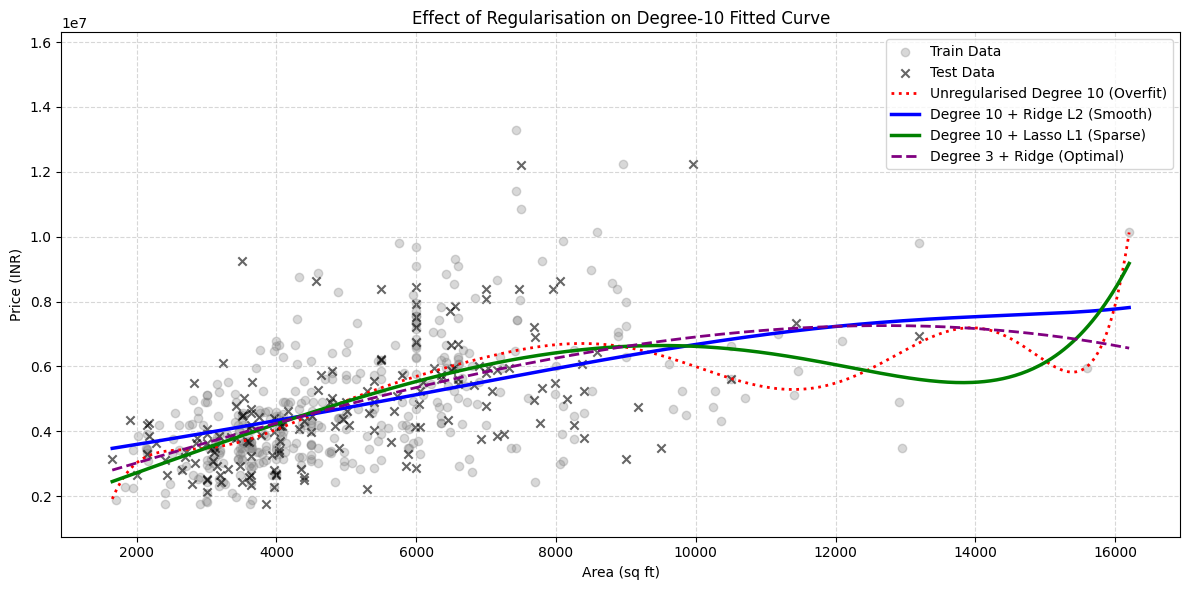

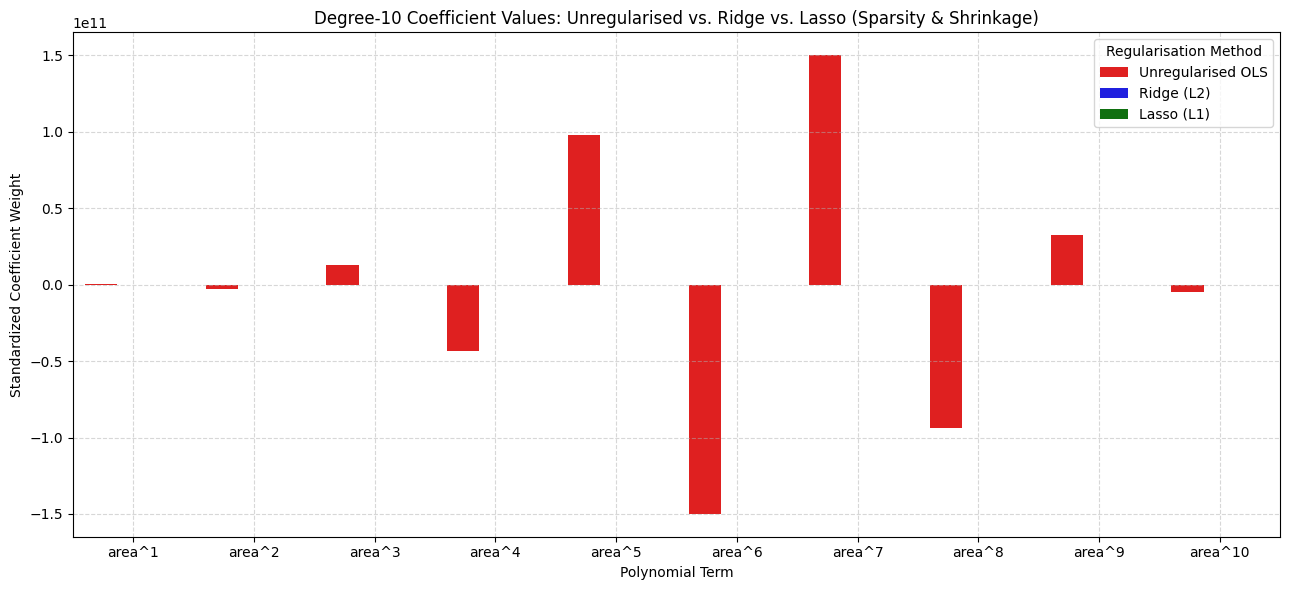

In [6]:
# 1. Plot fitted curves for Unregularised vs. Ridge vs. Lasso at Degree 10
plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, color='gray', alpha=0.3, label='Train Data')
plt.scatter(X_test, y_test, color='black', alpha=0.6, label='Test Data', marker='x')

plt.plot(x_range, pipe_ols10.predict(x_range_df), label='Unregularised Degree 10 (Overfit)', color='red', linestyle=':', lw=2)
plt.plot(x_range, pipe_ridge10.predict(x_range_df), label='Degree 10 + Ridge L2 (Smooth)', color='blue', lw=2.5)
plt.plot(x_range, pipe_lasso10.predict(x_range_df), label='Degree 10 + Lasso L1 (Sparse)', color='green', lw=2.5)
plt.plot(x_range, pipe_ridge3.predict(x_range_df), label='Degree 3 + Ridge (Optimal)', color='purple', lw=2, linestyle='--')

plt.ylim(y.min() - 1e6, y.max() + 3e6)
plt.title('Effect of Regularisation on Degree-10 Fitted Curve')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Coefficient Magnitude Comparison (Demonstrating Shrinkage & Sparsity)
coef_ols = pipe_ols10.named_steps['model'].coef_
coef_ridge = pipe_ridge10.named_steps['model'].coef_
coef_lasso = pipe_lasso10.named_steps['model'].coef_
poly_feature_names = [f'area^{i}' for i in range(1, d_target + 1)]

coef_df = pd.DataFrame({
    'Polynomial Exponent': poly_feature_names,
    'Unregularised OLS': coef_ols,
    'Ridge (L2)': coef_ridge,
    'Lasso (L1)': coef_lasso
})

coef_df_melted = coef_df.melt(id_vars='Polynomial Exponent', var_name='Regularisation Method', value_name='Coefficient Value')

plt.figure(figsize=(13, 6))
sns.barplot(x='Polynomial Exponent', y='Coefficient Value', hue='Regularisation Method', data=coef_df_melted, palette=['red', 'blue', 'green'])
plt.title('Degree-10 Coefficient Values: Unregularised vs. Ridge vs. Lasso (Sparsity & Shrinkage)')
plt.xlabel('Polynomial Term')
plt.ylabel('Standardized Coefficient Weight')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**7. Regularisation Path Analysis: Tuning the Regularisation Strength (Alpha)**

Evaluating the sensitivity of test $R^2$ and coefficient norms across varying magnitudes of $\alpha$ for both Ridge and Lasso.

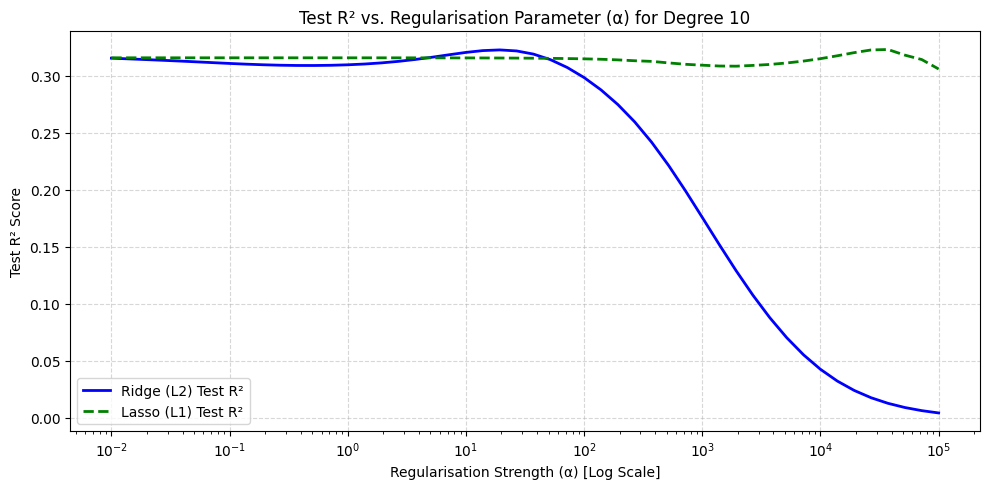

In [7]:
# define alpha search space on logarithmic grid
alphas = np.logspace(-2, 5, 50)
ridge_r2_scores = []
lasso_r2_scores = []

# compute test r2 across alpha values
for a in alphas:
    # evaluate ridge pipeline
    r_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=10, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=a))
    ])
    r_pipe.fit(X_train, y_train)
    ridge_r2_scores.append(r2_score(y_test, r_pipe.predict(X_test)))

    # evaluate lasso pipeline
    l_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=10, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=a, max_iter=10000))
    ])
    l_pipe.fit(X_train, y_train)
    lasso_r2_scores.append(r2_score(y_test, l_pipe.predict(X_test)))

# plot regularisation path vs test r2
plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_r2_scores, label='Ridge (L2) Test R²', color='blue', lw=2)
plt.plot(alphas, lasso_r2_scores, label='Lasso (L1) Test R²', color='green', lw=2, linestyle='--')
plt.xscale('log')
plt.title('Test R² vs. Regularisation Parameter (α) for Degree 10')
plt.xlabel('Regularisation Strength (α) [Log Scale]')
plt.ylabel('Test R² Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**8. Observations & Conclusion**

* **Polynomial Degree & Model Complexity:** At Degree 1 (linear baseline), the model achieves a Test $R^2$ of $0.3070$ and Train $R^2$ of $0.2788$, indicating slight underfitting due to the inability of a straight line to capture non-linear curvature in property pricing.
* **Tracking In-Sample Fit vs. Overfitting:** As polynomial complexity increases, Training MSE decreases monotonically from $2.5725 \times 10^{12}$ (Degree 1) down to $2.2684 \times 10^{12}$ (Degree 10), corresponding to a peak Training $R^2$ of $0.3641$. However, the Testing $R^2$ peaks at Degree 7 ($0.3219$) and drops to $0.3068$ at Degree 10, resulting in a positive generalization gap of $+2.9405 \times 10^{10}$ that marks the onset of overfitting.
* **Coefficient Instability:** The bar chart of standardized weights reveals that the unregularised OLS Degree-10 model experiences massive coefficient explosion, with higher-order terms ($\text{area}^6, \text{area}^7, \text{area}^8$) reaching magnitudes of $\pm 1.5 \times 10^{11}$. This mathematical instability causes the visible wave-like oscillations in the fitted curve between 10,000 and 16,000 sq ft.
* **Ridge ($L_2$) Regularisation (Coefficient Shrinkage):** Introducing the penalty $\alpha \sum \theta_j^2$ with $\alpha=100.0$ shrinks the explosive $\pm 1.5 \times 10^{11}$ coefficients toward zero without setting them to absolute zero. This dampens the polynomial oscillations and produces a smooth, monotonically increasing curve fit.
* **Lasso ($L_1$) Regularisation (Feature Sparsity):** Applying the $L_1$ penalty with $\alpha=10000.0$ sets 7 of the 10 polynomial coefficients to exact zero, retaining only 3 active terms. By discarding uninformative higher-order noise, Lasso improves the generalization performance, increasing Test $R^2$ from $0.3068$ to $0.3149$ and reducing Test MSE to $2.2711 \times 10^{12}$.
* **Optimal Model Selection:** Comparing all configurations demonstrates that an intermediate model (**Degree 3 + Ridge**) delivers the best overall generalization, achieving the highest Test $R^2$ score ($0.3219$) and lowest Test MSE ($2.2479 \times 10^{12}$) while preserving model parsimony(fit) and interpretability.